## Miscellaneous plots.  
Use de novo NDD data to get enrichments in mutation rate bins.  
Plot gene rescaled scores as a function of scores.  
Show examples of the variant update.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy as sc
from scipy.integrate import quad
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, roc_curve, roc_auc_score
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from scipy.stats import gmean, linregress, norm, beta, uniform, lognorm, pearsonr, spearmanr, poisson
from scipy.integrate import simpson, cumulative_trapezoid, trapezoid
from scipy.optimize import minimize
from scipy.special import logsumexp
from scipy.integrate import simpson
from scipy import stats
import glob
import os
import math
import re
import csv
from tqdm import tqdm
import time
import joblib
from joblib import Parallel, delayed, parallel_backend
import multiprocessing
import pickle
import random
import ast
import json
import Generate_missense

In [2]:
# Missense file
with open(f"/n/data2/hms/dbmi/sunyaev/lab/pkar/Missense_analysis/final/all_new_scores.pkl", "rb") as f:
    df_all_variants = pickle.load(f)

print("Done")

# Get LoF data
df_lof = pd.read_csv("../LoF_selection/LoF_s_het.txt.gz", sep="\t", compression="gzip")
df_all_variants = df_all_variants.merge(df_lof[["gene_id", "Posterior_CI10_lower"]], on="gene_id", how="left")

# Remove CES genes
CE_genes = np.array(['ENSG00000078369', 'ENSG00000157933', 'ENSG00000198793', 'ENSG00000117713', 'ENSG00000117400', 'ENSG00000213281', 'ENSG00000143379', 'ENSG00000143622',
                     'ENSG00000135829', 'ENSG00000117139', 'ENSG00000171862', 'ENSG00000108055', 'ENSG00000108061', 'ENSG00000148737', 'ENSG00000066468', 'ENSG00000174775',
                     'ENSG00000184937', 'ENSG00000149480', 'ENSG00000168066', 'ENSG00000175115', 'ENSG00000160584', 'ENSG00000110395', 'ENSG00000111262', 'ENSG00000273079',
                     'ENSG00000133703', 'ENSG00000110844', 'ENSG00000111252', 'ENSG00000179295', 'ENSG00000083642', 'ENSG00000136158', 'ENSG00000176165', 'ENSG00000119596',
                     'ENSG00000179364', 'ENSG00000140262', 'ENSG00000169032', 'ENSG00000137834', 'ENSG00000080603', 'ENSG00000102962', 'ENSG00000174231', 'ENSG00000141510',
                     'ENSG00000196712', 'ENSG00000178691', 'ENSG00000136450', 'ENSG00000170836', 'ENSG00000141376', 'ENSG00000087191', 'ENSG00000161547', 'ENSG00000101752',
                     'ENSG00000152217', 'ENSG00000141646', 'ENSG00000134440', 'ENSG00000256463', 'ENSG00000105204', 'ENSG00000263002', 'ENSG00000160007', 'ENSG00000087088',
                     'ENSG00000063244', 'ENSG00000115758', 'ENSG00000119772', 'ENSG00000213639', 'ENSG00000198369', 'ENSG00000136710', 'ENSG00000115524', 'ENSG00000204217',
                     'ENSG00000036257', 'ENSG00000101266', 'ENSG00000171456', 'ENSG00000244462', 'ENSG00000124233', 'ENSG00000156304', 'ENSG00000159216', 'ENSG00000160201',
                     'ENSG00000099949', 'ENSG00000254709', 'ENSG00000183765', 'ENSG00000099995', 'ENSG00000100393', 'ENSG00000172936', 'ENSG00000168036', 'ENSG00000181555',
                     'ENSG00000169855', 'ENSG00000118007', 'ENSG00000155903', 'ENSG00000159692', 'ENSG00000068078', 'ENSG00000168769', 'ENSG00000113163', 'ENSG00000185129',
                     'ENSG00000145907', 'ENSG00000181163', 'ENSG00000165671', 'ENSG00000204469', 'ENSG00000204435', 'ENSG00000112640', 'ENSG00000171467', 'ENSG00000146247',
                     'ENSG00000164494', 'ENSG00000049618', 'ENSG00000065883', 'ENSG00000146830', 'ENSG00000005483', 'ENSG00000064419', 'ENSG00000157764', 'ENSG00000158941',
                     'ENSG00000164754', 'ENSG00000169249', 'ENSG00000215301', 'ENSG00000126752', 'ENSG00000072501', 'ENSG00000177485', 'ENSG00000101972', 'ENSG00000156531', 
                     'ENSG00000165509', 'ENSG00000167548'])

df_all_variants = df_all_variants[~(df_all_variants["gene_id"].isin(CE_genes))]

Done


In [7]:
# Load the synonymous GnomAD dataset
df_syn = pd.read_csv("../Data/synonymous_data.txt.gz", sep="\t", compression="gzip")

# Kaplanis et al. NDD de novo data mutations
df_NDD = pd.read_csv("../Data/missense/DNW_clean_syn.txt.gz", sep="\t", compression="gzip")

df_NDD_filtered = df_NDD[~(df_NDD["chromosome"] == "X")]
df_NDD_filtered = df_NDD_filtered.rename(columns={"chromosome": "#CHROM", "position": "POS", "ref": "REF", "alt": "ALT"})

df_NDD_filtered["#CHROM"] = df_NDD_filtered["#CHROM"].astype(int)
df_NDD_filtered["POS"] = df_NDD_filtered["POS"].astype(int)
df_NDD_filtered["REF"] = df_NDD_filtered["REF"].astype(str)
df_NDD_filtered["ALT"] = df_NDD_filtered["ALT"].astype(str)

# Group by and count. Count per position and allele in the de novo dataset
df_NDD_counts = (df_NDD_filtered.groupby(['POS', 'REF', 'ALT', '#CHROM']).size().reset_index(name='mutations_1'))
# Merge with synonymous data
df_syn_merged = pd.merge(df_syn[["#CHROM", "POS", "REF", "ALT", "MR", "gene_id", "allele_count", "allele_number"]], df_NDD_counts, on=["#CHROM", "POS", "REF", "ALT"], how="left")  # or "inner" depending on whether you want to retain all rows in df1 or only matches
df_syn_merged["mutations_1"] = df_syn_merged["mutations_1"].fillna(0)
# Find scaling
scaling = df_syn_merged["mutations_1"].sum() / df_syn_merged["MR"].sum()

# Step 3: Merge with missense dataframe
df_all_variants_full = df_all_variants.merge(df_NDD_counts, on=["#CHROM", "POS", "REF", "ALT"], how="left")
# Step 4: Fill NaN values (i.e., no match) with 0
df_all_variants_full["mutations_1"] = df_all_variants_full["mutations_1"].fillna(0)
# Get scaled expected mutation count
df_all_variants_full["Scaled_MR_1"] = df_all_variants_full["MR"] * scaling

/tmp/ipykernel_2804615/1210684132.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_NDD = pd.read_csv("../Data/missense/DNW_clean_syn.txt.gz", sep="\t", compression="gzip")


In [ ]:
label_methods = {"AlphaMissense":"AlphaMissense", "popEVE_neg":"popEVE", "esm_score_neg":"ESM-1b", "ESM_1v_neg":"ESM-1v", "cadd_score":"CADD",
                 "MPC":"MPC", "MisFit_D":"MisFit_D", "MisFit_S": "MisFit_S", "PrimateAI-3D": "PrimateAI-3D", "REVEL": "REVEL", 
                 "s_prior_AlphaMissense_norm": "PIES-Mis AlphaMissense prior", "s_AlphaMissense_norm": "PIES-Mis AlphaMissense posterior", 
                 "s_prior_popEVE_neg": "PIES-Mis popEVE prior", "s_popEVE_neg": "PIES-Mis popEVE posterior", 
                 "s_prior_esm_score_neg": "PIES-Mis ESM-1b prior", "s_esm_score_neg": "PIES-Mis ESM-1b posterior"}


method_colors = {
    # --- Base models (medium tone) ---
    "AlphaMissense": "#1f77b4",      # blue
    "popEVE_neg": "#d62728",         # red
    "esm_score_neg": "#2ca02c",      # green

    # --- PIES (variant-level): darker ---
    "s_AlphaMissense_norm": "#0b3c5d",   # dark blue
    "s_popEVE_neg": "#7f0000",           # dark red
    "s_esm_score_neg": "#145a32",        # dark green

    # --- PIES gene-level: lighter ---
    "s_prior_AlphaMissense_norm": "#6baed6",  # light blue
    "s_prior_popEVE_neg": "#f4a6a6",          # light red
    "s_prior_esm_score_neg": "#98df8a",       # light green

    # --- Other methods (unchanged) ---
    "ESM_1v_neg": "#17becf",
    "cadd_score": "#9467bd",
    "MPC": "#8c564b",
    "MisFit_D": "#e377c2",
    "MisFit_S": "#7f7f7f",
    "PrimateAI-3D": "#bcbd22",
    "REVEL": "#ff7f0e",
}


#### Get enrichment in de novo data for each score in different mutation rate bins

In [6]:
# Enrichment in top 5% NDD 
def enrichment_top_by_logMR_bin(df, score_cols, label_scores, mu_col="MR", obs_col="mutations_1", exp_col="Scaled_MR_1", frac=0.05,
                                n_bins=10, plot=True, file_name = None):
    """
    Bin variants by log10(mu_col) into n_bins bins.
    Plot enrichment vs MR-bin center.
    """

    df = df.copy()

    df["logMR"] = np.log10(df[mu_col].values)

    logMR = df["logMR"].values
    log_edges = np.linspace(logMR.min(), logMR.max(), n_bins + 1)
    df["MR_bin"] = np.searchsorted(log_edges, logMR, side='right') - 1
    df["MR_bin"] = df["MR_bin"].clip(0, n_bins - 1)

    # Compute bin centers for plotting
    bin_centers = 0.5 * (log_edges[:-1] + log_edges[1:])

    results = {}

    for score in score_cols:
        ratios = []
        errors = []
        obvs = []
        exps = []
        pct = []

        for b in range(n_bins):
            sub = df[df["MR_bin"] == b]

            if len(sub) == 0:
                ratios.append(np.nan)
                errors.append(np.nan)
                pct.append(0.0)
                obvs.append(0.0)
                exps.append(0.0)
                continue

            N_total = len(sub)
            x = sub[score].values

            # top 5% cutoff
            thr = np.nanquantile(x, 1 - frac)
            mask = x >= thr

            sub_top = sub[mask]
            N_top = mask.sum()

            if N_top == 0:
                ratios.append(np.nan)
                errors.append(np.nan)
                pct.append(0.0)
                obvs.append(0.0)
                exps.append(0.0)
                continue

            # Observed and Expected
            O = sub_top[obs_col].sum()
            E = sub_top[exp_col].sum()

            if E > 0:
                ratio = O / E
                err = np.sqrt(O) / E
            else:
                ratio = np.nan
                err = np.nan

            ratios.append(ratio)
            errors.append(err)
            pct.append(N_top / N_total)
            obvs.append(O)
            exps.append(E)

        results[score] = {
            "bin_centers": bin_centers,
            "ratio": np.array(ratios),
            "err": np.array(errors),
            "percent_included": np.array(pct),
            "obs": np.array(obvs),
            "exp": np.array(exps)
        }

    if plot:
        fig, ax = plt.subplots(figsize=(6.2, 4.6))

        for score in score_cols:
            r = results[score]["ratio"]
            e = results[score]["err"]
            bc = 10**(results[score]["bin_centers"])

            ax.errorbar(
                bc[1:], r[1:], yerr=e[1:],
                fmt="o-", lw=2.0, ms=5.5, capsize=3, elinewidth=1.2,
                color=method_colors[score],
                label=label_scores.get(score, score)
            )

        ax.set_xlabel("Mutation rate", fontsize=14)
        ax.set_ylabel("Observed / expected", fontsize=14)
        ax.set_xscale("log")

        ax.tick_params(axis="both", which="major", labelsize=11, length=5, width=1)
        ax.tick_params(axis="both", which="minor", length=3, width=0.8)

        # ax.spines["top"].set_visible(False)
        # ax.spines["right"].set_visible(False)
        # ax.spines["left"].set_linewidth(1)
        # ax.spines["bottom"].set_linewidth(1)

        ax.grid(False)
        ax.legend(frameon=False, fontsize=12)

        fig.tight_layout()

        if file_name is not None:
            plt.savefig(file_name, dpi=300, bbox_inches='tight')
            
        plt.show()

    return results


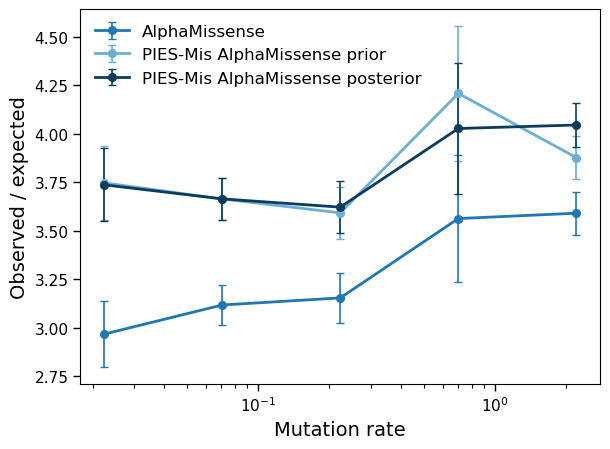

In [7]:
scores = ["AlphaMissense", "s_prior_AlphaMissense_norm", "s_AlphaMissense_norm"]
results = enrichment_top_by_logMR_bin(df_all_variants_full, score_cols=scores, label_scores = label_methods, mu_col= "MR", frac=0.05, n_bins=6, file_name = "../Figures/Mut_bin_OE.svg")

# Plot gene rescaled scores against the score themselves

Select dominant genes

In [3]:
with open("../Data/missense/GG_EVAL/genemap2_dom_not_rec_ENS.txt") as f:
    dom_gene_list = [line.strip() for line in f if line.strip()]

In [4]:
df_dom_variants = df_all_variants[df_all_variants["gene_id"].isin(dom_gene_list)]

Load ClinVar data

In [7]:
# Load ClinVar
df_clinvar = pd.read_csv("/n/scratch/users/p/prk534/Missense/variant_summary.txt.gz", sep = "\t", compression = "gzip")

/tmp/ipykernel_406171/88718125.py:2: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clinvar = pd.read_csv("/n/scratch/users/p/prk534/Missense/variant_summary.txt.gz", sep = "\t", compression = "gzip")


In [8]:
# Filter SNVs in autosomes on Hg38 assembly which are Benign, Likely Benign, Pathogenic, or Likely Pathogenic with 1+ star review
df_clinvar_filtered = df_clinvar[(df_clinvar['Type'] == 'single nucleotide variant') & 
    (df_clinvar['ClinicalSignificance'].isin(['Pathogenic', 'Likely pathogenic', 'Pathogenic/Likely pathogenic']))
    & (df_clinvar['Assembly']=='GRCh38') & 
    (df_clinvar['ReviewStatus'].isin(['criteria provided, multiple submitters, no conflicts', 'criteria provided, single submitter', 'reviewed by expert panel', 'practice guideline']))
    & ~(df_clinvar['Chromosome'].isin(['X', 'Y', 'MT', 'na', 'Un']))]

df_clinvar_filtered["Chromosome"] = (df_clinvar_filtered["Chromosome"].astype(str).astype(int))
df_clinvar_filtered = df_clinvar_filtered[(df_clinvar_filtered["ReferenceAlleleVCF"].isin(['A', 'T', 'C', 'G'])) &
    (df_clinvar_filtered["AlternateAlleleVCF"].isin(['A', 'T', 'C', 'G']))]

df_clinvar_filtered["clinvar_path"] = 1

df_clinvar_clean = df_clinvar_filtered[['Chromosome', 'PositionVCF', 'ReferenceAlleleVCF', 'AlternateAlleleVCF', 'clinvar_path']]
df_clinvar_clean = df_clinvar_clean.rename(columns = {'Chromosome': '#CHROM', 'PositionVCF':'POS', 'ReferenceAlleleVCF':'REF', 'AlternateAlleleVCF':'ALT'})

df_dom_variants = df_dom_variants.merge(df_clinvar_clean, on = ["#CHROM", "POS", "REF", "ALT"], how = "left")
df_dom_variants

/tmp/ipykernel_406171/3338316820.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clinvar_filtered["Chromosome"] = (df_clinvar_filtered["Chromosome"].astype(str).astype(int))


,gene_id,proteinmpnn_llr_neg,rasp_score,polyphen_score,cpt1_score,popEVE_neg,ESM_1v_neg,cadd_score,gpn_msa_score,#CHROM,...,MR_rank,AlphaMissense_norm,s_prior_AlphaMissense_norm,s_AlphaMissense_norm,s_prior_popEVE_neg,s_popEVE_neg,s_prior_esm_score_neg,s_esm_score_neg,Posterior_CI10_lower,clinvar_path
0,ENSG00000107404,0.57735,-0.025392,0.838,0.348350,3.788,6.286,3.89340,-12.28,1,...,3.0,1.009205,0.011807,0.011807,0.002161,0.002161,0.006075,0.006075,0.019079,NaN
1,ENSG00000107404,0.57735,-0.025392,0.838,0.348350,3.788,6.286,3.92460,-12.01,1,...,4.0,1.009205,0.011807,0.011807,0.002161,0.002161,0.006075,0.006304,0.019079,NaN
2,ENSG00000107404,0.57735,-0.025392,0.838,0.348350,3.788,6.286,3.96600,-10.39,1,...,20.0,1.009205,0.011807,0.013190,0.002161,0.002327,0.006075,0.006541,0.019079,NaN
3,ENSG00000107404,0.23162,-0.253190,0.917,0.558910,4.045,9.048,4.85070,-12.60,1,...,5.0,0.861307,0.009461,0.009817,0.004200,0.004200,0.017079,0.017721,0.019079,NaN
4,ENSG00000107404,0.28562,-0.003614,0.838,0.363320,3.848,5.924,4.06120,-10.34,1,...,40.0,0.884676,0.009817,0.008788,0.002505,0.002505,0.010569,0.009461,0.019079,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5885771,ENSG00000075275,NaN,1.824100,0.015,0.175610,NaN,NaN,0.36508,-3.71,22,...,5.0,-1.752042,0.000254,0.000254,NaN,NaN,0.000714,0.000714,0.041422,NaN
5885772,ENSG00000075275,NaN,1.468100,0.124,0.249470,NaN,NaN,1.38630,-3.45,22,...,4.0,-1.562000,0.000329,0.000329,NaN,NaN,0.001289,0.001289,0.041422,NaN
5885773,ENSG00000075275,NaN,1.068800,0.010,0.042366,NaN,NaN,-0.41495,-1.77,22,...,20.0,-2.223513,0.000126,0.000131,NaN,NaN,0.000305,0.000305,0.041422,NaN
5885774,ENSG00000075275,NaN,0.788140,0.006,0.052942,NaN,NaN,-0.42204,-2.01,22,...,5.0,-2.276000,0.000121,0.000121,NaN,NaN,0.000512,0.000512,0.041422,NaN


Select genes to plot. Genes have similar AlphaMissense geometric mean

In [9]:
gene_stats = df_dom_variants.groupby('gene_id').agg({
    'AlphaMissense': lambda x: np.nanmedian(x),
    's_prior_AlphaMissense_norm': lambda x: gmean(x.dropna()) if not x.dropna().empty else np.nan
})

# Example: Finding genes with AlphaMissense ~ 0.5 but vastly different s
target_am = 0.5
tolerance = 0.05

similar_am_genes = gene_stats[
    (gene_stats['AlphaMissense'] > target_am - tolerance) & 
    (gene_stats['AlphaMissense'] < target_am + tolerance)
]

# Sort by s_value to find the extremes
extremes = similar_am_genes.sort_values('s_prior_AlphaMissense_norm')
print(extremes.head(10)) # Low s (less constrained than AM predicts)
print(extremes.tail(6)) # High s (more constrained than AM predicts)

/tmp/ipykernel_406171/2615637670.py:2: RuntimeWarning: All-NaN slice encountered
  'AlphaMissense': lambda x: np.nanmedian(x),


                 AlphaMissense  s_prior_AlphaMissense_norm
gene_id                                                   
ENSG00000143318        0.45965                    0.000861
ENSG00000162040        0.47905                    0.000949
ENSG00000106211        0.49900                    0.001566
ENSG00000161798        0.49460                    0.001574
ENSG00000176692        0.45185                    0.002096
ENSG00000179520        0.47530                    0.002225
ENSG00000164111        0.45380                    0.002465
ENSG00000250479        0.47680                    0.002574
ENSG00000091010        0.45040                    0.002718
ENSG00000125850        0.48720                    0.002793
                 AlphaMissense  s_prior_AlphaMissense_norm
gene_id                                                   
ENSG00000151617        0.45100                    0.036434
ENSG00000147862        0.53470                    0.039297
ENSG00000198963        0.48620                    0.0401

In [23]:
df_all_variants.columns

Index(['gene_id', 'proteinmpnn_llr_neg', 'rasp_score', 'polyphen_score',
       'cpt1_score', 'popEVE_neg', 'ESM_1v_neg', 'cadd_score', 'gpn_msa_score',
       '#CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'MR', 'gene_symbol',
       'AlphaMissense', 'MPC', 'esm_score_neg', 'allele_count',
       'allele_number', 'MisFit_D', 'MisFit_S', 'PrimateAI-3D', 'REVEL',
       'MR_rank', 'AlphaMissense_norm', 's_prior_AlphaMissense_norm',
       's_AlphaMissense_norm', 's_prior_popEVE_neg', 's_popEVE_neg',
       's_prior_esm_score_neg', 's_esm_score_neg', 'Posterior_CI10_lower'],
      dtype='object')

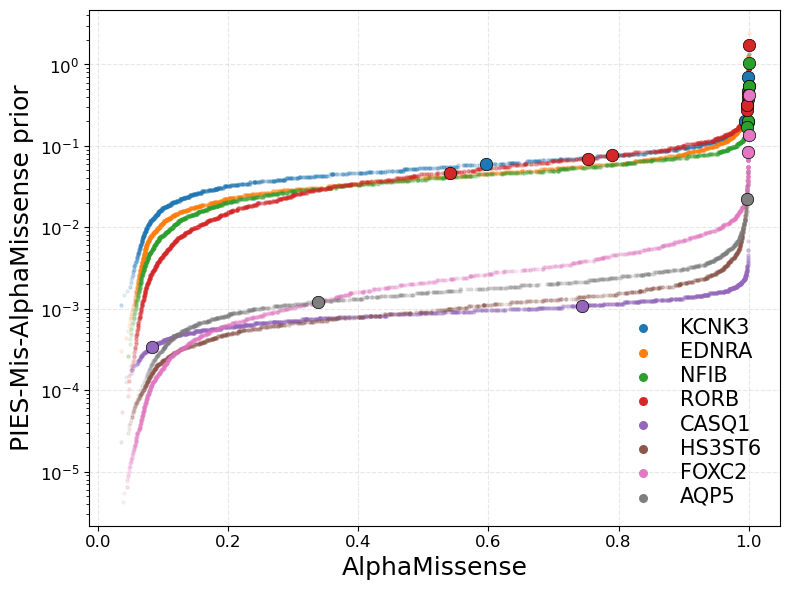

In [ ]:
# We plot the AlphaMissense vs s_prior_AlphaMissense_norm for these genes, highlighting ClinVar pathogenic variants in circles. 
# 1. Define the target genes based on your recent analysis
# CNOT3/STAC + Top 3 from tail (high s) + Top 3 from head (low s)
target_genes = {
    # High s genes (more constrained than AM predicts)
    'ENSG00000171303': 'KCNK3',
    'ENSG00000151617': 'EDNRA',
    'ENSG00000147862': 'NFIB',
    'ENSG00000198963': 'RORB',
    # Low s genes (less constrained than AM predicts)
    'ENSG00000143318': 'CASQ1',
    'ENSG00000162040': 'HS3ST6',
    'ENSG00000176692': 'FOXC2',
    'ENSG00000161798': 'AQP5'
}

# 2. Setup the figure: 2 rows of 4 plots
fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharey=True)

# Define a color cycle or a specific map to ensure each gene gets a unique color
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

for i, (gene_id, symbol) in enumerate(target_genes.items()):
    
    # Filter data for this specific gene
    gene_df = df_dom_variants[df_dom_variants['gene_id'] == gene_id].copy()
    
    if gene_df.empty:
        continue

    # Pick a color for this gene based on the index
    gene_color = colors[i % len(colors)]
    
    # Plot Background (Gray)
    ax.scatter(gene_df['AlphaMissense'], (gene_df['s_prior_AlphaMissense_norm']), s=5, color=gene_color, alpha =0.1, label=f'{symbol}')

    # Plot ClinVar Pathogenic (Red)
    # Check if 'clinvar_path' column exists; otherwise, check the merge source
    if 'clinvar_path' in gene_df.columns:
        clinvar = gene_df[gene_df['clinvar_path'] == 1]
        ax.scatter(clinvar['AlphaMissense'], (clinvar['s_prior_AlphaMissense_norm']), 
                   color=gene_color, edgecolors='black', linewidths=0.5, s=80, zorder=5)

    # Formatting each subplot
    ax.set_yscale('log')
    ax.set_xlabel("AlphaMissense", fontsize = 18)
    ax.set_ylabel("PIES-Mis-AlphaMissense prior", fontsize = 18)
    ax.grid(True, linestyle='--', alpha=0.3)

# Place legend outside on the right
leg = plt.legend(frameon = False, fontsize = 15, loc = "lower right", labelspacing=0.2)
for handle in leg.legend_handles:
    handle.set_alpha(1.0)       # Remove transparency in the legend
    handle.set_sizes([30])      # Set a consistent, larger dot size

# For the current plot using plt
plt.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig("../Figures/s_vs_AM.svg", dpi=300, bbox_inches='tight')
plt.show()

#### Update the gene rescaled scores at the variant level

In [8]:
unique_MR = df_all_variants_full['MR'].unique()
MR_rank_dict = {value: rank for rank, value in enumerate(sorted(unique_MR))}

# Assign the rank to each row based on 'MR' values
df_all_variants_full['MR_rank'] = df_all_variants_full['MR'].map(MR_rank_dict)

In [9]:
folder = "/n/data2/hms/dbmi/sunyaev/lab/pkar/Missense_analysis/final/gene_mle_results_AlphaMissense_norm"

# List all the txt files
file_list = glob.glob(f"{folder}/*.txt")

# Read and concatenate into a DataFrame
df_summary = pd.concat([
    pd.read_csv(f, sep="\t", header=None,
                names=["gene_id", "c", "beta", "sigma", "max_log_likelihood", "success", "n_sites"])
    for f in file_list
], ignore_index=True)

In [10]:
# 4) load SFSs
sfs_variant_pkl="/n/data2/hms/dbmi/sunyaev/lab/pkar/demography_SFS/SFS_all.pkl"
sfs_variant = Generate_missense.load_sfs(sfs_variant_pkl)
s_values_variant = -np.logspace(-6, 2, num=500)

In [22]:
print(df_all_variants_full.columns)

Index(['gene_id', 'proteinmpnn_llr_neg', 'rasp_score', 'polyphen_score',
       'cpt1_score', 'popEVE_neg', 'ESM_1v_neg', 'cadd_score', 'gpn_msa_score',
       '#CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'MR', 'gene_symbol',
       'AlphaMissense', 'MPC', 'esm_score_neg', 'allele_count',
       'allele_number', 'MisFit_D', 'MisFit_S', 'PrimateAI-3D', 'REVEL',
       'MR_rank', 'AlphaMissense_norm', 's_prior_AlphaMissense_norm',
       's_AlphaMissense_norm', 's_prior_popEVE_neg', 's_popEVE_neg',
       's_prior_esm_score_neg', 's_esm_score_neg', 'Posterior_CI10_lower',
       'mutations_1', 'Scaled_MR_1'],
      dtype='object')


In [ ]:
# Plot likelihood(s) and posterior for selected variants
def plot_likelihood_and_unnorm_post(df_rows, sfs, df_summary, 
                                    score_col="AlphaMissense_norm", ac_col="allele_count", mr_col="MR_rank", 
                                    log_bounds=(-6, 2), n_grid=500, ncols=3, figsize_per_col=6, fig_name = None):
    """
    df_rows: a DataFrame with the selected variant rows (can be one or many).
             Must contain columns: score_col, ac_col, mr_col.
    sfs:     3D array; indexed as sfs[MR_rank, :-1, allele_count] -> (S,)
    c, beta, sigma: parameters for mu = a*esm + b, lognormal shape = sigma*ln(10), scale = 10**mu
    """

    if df_rows.empty:
        print("No rows to plot.")
        return

    # grid in log10(-s)
    log_s = np.linspace(log_bounds[0], log_bounds[1], n_grid)
    s_grid = 10 ** log_s
    ln10   = np.log(10)
    zmin, zmax = log_bounds

    rows = list(df_rows.itertuples(index=False))
    n = len(rows)
    ncols = max(1, min(ncols, n))
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_col*ncols, 4*nrows), squeeze=False)

    for i, row in enumerate(rows):
        ax = axes[i // ncols, i % ncols]

        score = float(getattr(row, score_col))
        k   = int(getattr(row, ac_col))
        mr  = int(getattr(row, mr_col))
        gene = getattr(row, "gene_id")

        row_summary = df_summary.loc[df_summary.gene_id == gene]
        if row_summary.empty:
            continue
        c, beta, sigma = row_summary.iloc[0][["c", "beta", "sigma"]]

        # Prior (as-is)
        mu    = zmin + (zmax - zmin) * (1.0 / (1.0 + np.exp(-beta * (score - c))))
        scale = 10 ** np.clip(mu, -300, 300)   # numeric safety
        shape  = sigma * ln10
        prior_pdf = lognorm.pdf(s_grid, s=shape, scale=scale)

        # Prior delta masses at bounds (outside [zmin, zmax] in log10-space)
        dl_prior = norm.cdf(zmin, loc=mu, scale=sigma)
        du_prior = norm.sf (zmax, loc=mu, scale=sigma)

        # Likelihood (unnormalized)
        like = np.asarray(sfs[mr, :-1, k]).ravel()

        # Unnormalized posterior
        post_unnorm = prior_pdf * like

        # Posterior delta masses (weighted by likelihood at ends)
        post_lower = dl_prior * like[0]
        post_upper = du_prior * like[-1]

        # Normalize posterior for plotting and median computation
        cont_mass = trapezoid(post_unnorm, s_grid)
        tot_mass  = post_lower + cont_mass + post_upper
        if tot_mass <= 0:
            # fallback to avoid NaNs
            print("Row is problematic")
            print(row)
            continue
        else:
            pdf_cont = post_unnorm / tot_mass   # proper posterior pdf over s_grid
            dl_post  = post_lower / tot_mass
            du_post  = post_upper / tot_mass

        # Prior CDF including lower delta
        cdf_cont_prior = cumulative_trapezoid(prior_pdf, s_grid, initial=0.0)
        cdf_prior = dl_prior + cdf_cont_prior
        cdf_prior[-1] += du_prior  # add upper delta at the end

        # Posterior median (first point where CDF >= 0.5)
        idx_med_prior = int(np.argmax(cdf_prior >= 0.5))
        log_s_med_prior = s_grid[idx_med_prior]

        # Posterior CDF including lower delta
        cdf_cont = cumulative_trapezoid(pdf_cont, s_grid, initial=0.0)
        cdf = dl_post + cdf_cont
        cdf[-1] += du_post  # add upper delta at the end

        # Posterior median (first point where CDF >= 0.5)
        idx_med = int(np.argmax(cdf >= 0.5))
        log_s_med = s_grid[idx_med]

        # PRIOR / LIKELIHOOD / POSTERIOR (clear hierarchy)
        prior_line, = ax.plot(s_grid, prior_pdf, lw=3, alpha=0.85, label="Prior")
        like_scaled = like / np.nanmax(like)
        like_scaled = like_scaled * max(np.nanmax(prior_pdf), np.nanmax(pdf_cont))
        like_line,  = ax.plot(s_grid, like_scaled, lw=3, alpha=0.70, label="Per-variant likelihood")
        post_line,  = ax.plot(s_grid, pdf_cont,  lw=3, alpha=0.95, label="Posterior")
        
        # Axes / scales
        ax.set_xlabel(r"Selection coefficient", fontsize=15)
        ax.set_ylabel("Density", fontsize=15)
        ax.set_xscale("log")
        ax.set_xlim(1e-4,1)
        
        ax.tick_params(axis="both", which="major", labelsize=10, length=4, width=1)
        ax.tick_params(axis="both", which="minor", length=2.5, width=0.8)
        
        # Clean legend (deduplicate + order)
        handles, labels = ax.get_legend_handles_labels()
        order = ["Prior", "Per-variant likelihood", "Posterior"]
        uniq = {}
        for h, l in zip(handles, labels):
            if l not in uniq:
                uniq[l] = h
        handles = [uniq[l] for l in order if l in uniq]
        labels  = [l for l in order if l in uniq]
        ax.legend(handles, labels, frameon=False, fontsize=12, handlelength=2.2, loc="best")

    # Hide unused subplots
    for j in range(i+1, nrows*ncols):
        axes[j // ncols, j % ncols].axis("off")

    plt.tight_layout()
    if fig_name is not None:
        plt.savefig(fig_name, bbox_inches="tight", dpi=300)
    plt.show()

In [8]:
df_plot = df_all_variants_full[(df_all_variants_full["s_AlphaMissense_norm"]>0.1) & (df_all_variants_full["s_AlphaMissense_norm"]<0.2) &
                               (df_all_variants_full["s_prior_AlphaMissense_norm"]>0.05) & (df_all_variants_full["s_prior_AlphaMissense_norm"]<0.08) & 
                               (df_all_variants_full["allele_count"]==0) & (df_all_variants_full["MR"]>1)]
plot_likelihood_and_unnorm_post(df_plot.iloc[0:1], sfs_variant, df_summary, score_col="AlphaMissense_norm", ac_col="allele_count", mr_col="MR_rank", fig_name="../Figures/var_update_CpG.svg")

In [ ]:
df_plot = df_all_variants_full[(df_all_variants_full["s_prior_AlphaMissense_norm"]>0.1) & (df_all_variants_full["s_prior_AlphaMissense_norm"]<0.2) &
                               (df_all_variants_full["s_AlphaMissense_norm"]>0.05) & (df_all_variants_full["s_AlphaMissense_norm"]<0.08) &
                               (df_all_variants_full["allele_count"]>1) & (df_all_variants_full["allele_count"]<3)
                               ]
plot_likelihood_and_unnorm_post(df_plot.iloc[[0]], sfs_variant, df_summary, score_col="AlphaMissense_norm", ac_col="allele_count", mr_col="MR_rank", fig_name= "../Figures/var_update_nonCpG.svg")